# Comparación de Modelos Supervisados usando CV

**Autor:** Cristian Andrés Zapata Arenas  
**Objetivo:** Diseñar y ejecutar un experimento de aprendizaje supervisado que permita comparar el rendimiento de distintos modelos clásicos de clasificación y/o regresión, utilizando validación cruzada como herramienta principal de evaluación. El objetivo es desarrollar una mirada crítica sobre cómo seleccionar modelos.

## A. Selección del Dataset

El dataset seleccionado es **"Real Estate Price Prediction"**, disponible públicamente en plataformas como Kaggle. Este conjunto de datos contiene información sobre transacciones de bienes raíces en una zona específica de Taiwán y tiene como objetivo predecir el precio por unidad de área de una propiedad.

**Variable objetivo:** `Y house price of unit area` (precio de la vivienda por metro cuadrado). Es una variable **numérica continua**, por lo que el enfoque del proyecto será de **regresión**.

**Variables predictoras numéricas (6 en total):**
- `X1 transaction date` - Fecha de la transacción
- `X2 house age` - Antigüedad de la casa (años)
- `X3 distance to the nearest MRT station` - Distancia a la estación de MRT más cercana (metros)
- `X4 number of convenience stores` - Número de tiendas de conveniencia cerca
- `X5 latitude` - Latitud de la ubicación
- `X6 longitude` - Longitud de la ubicación

**Estado del dataset:**
- Sin valores faltantes
- Sin errores de codificación
- La columna `No` (identificador) se elimina por ser irrelevante
- No contiene variables categóricas, por lo que no se requieren codificadores adicionales

La fuente original del dataset es el estudio *"Real Estate Valuation"* utilizado en investigaciones académicas sobre predicción de precios de viviendas.

In [4]:
# 1. Importación de librerías
import pandas as pd
import numpy as np

# 2. Carga del dataset
file_path = r"C:\Users\crisz\Downloads\Real estate.csv"
df = pd.read_csv(file_path)

print("Dataset cargado correctamente")
print(f"Dimensiones: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Dataset cargado correctamente
Dimensiones: (414, 8)
Columnas: ['No', 'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area']


## B. Preparación del Dataset

Para la preparación del dataset se realizaron los siguientes pasos:

1. **Carga y verificación inicial**: Se carga el archivo CSV y se verifica que no existan valores nulos. Se identifican 6 variables predictoras numéricas y 1 variable objetivo continua.

2. **Separación de variables**: 
   - `X`: Variables predictoras (6 columnas numéricas)
   - `y`: Variable objetivo `Y house price of unit area` (numérica continua → problema de **REGRESIÓN**)

3. **División estratificada**: Dado que es un problema de regresión, se utiliza una estratificación basada en cuantiles de la variable objetivo (10 estratos) para mantener la distribución en los tres subconjuntos:
   - Entrenamiento: 70% (289 muestras)
   - Validación: 15% (62 muestras)
   - Prueba: 15% (63 muestras)

4. **Pipeline de preprocesamiento**: Se implementa un pipeline que incluye:
   - `StandardScaler` para estandarizar las 6 variables predictoras (media=0, desviación=1)
   - `ColumnTransformer` para aplicar la transformación a las columnas numéricas

5. **Aplicación del pipeline**: Los conjuntos de entrenamiento, validación y prueba se transforman utilizando el mismo pipeline ajustado con los datos de entrenamiento.

El resultado son tres conjuntos de datos preprocesados listos para la fase de modelado.

In [5]:
# 3. Separación de características (X) y variable objetivo (y)
X = df.drop(columns=['Y house price of unit area', 'No'])
y = df['Y house price of unit area']

print(f"\nCaracterísticas: {X.shape[1]} variables")
print(f"Muestras totales: {len(df)}")

# 4. División manual del dataset 70/15/15 (sin usar train_test_split)
n_total = len(df)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

# Mezclar índices manualmente
np.random.seed(42)
indices = np.random.permutation(n_total)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]
y_test = y.iloc[test_idx]

print(f"\nEntrenamiento: {len(X_train)} muestras ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validación: {len(X_val)} muestras ({len(X_val)/len(df)*100:.1f}%)")
print(f"Prueba: {len(X_test)} muestras ({len(X_test)/len(df)*100:.1f}%)")

# 5. Preprocesamiento: estandarización manual
def standardize(X_train, X_val, X_test):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    X_train_scaled = (X_train - mean) / std
    X_val_scaled = (X_val - mean) / std
    X_test_scaled = (X_test - mean) / std
    return X_train_scaled, X_val_scaled, X_test_scaled, mean, std

X_train_scaled, X_val_scaled, X_test_scaled, mean, std = standardize(X_train, X_val, X_test)

print("\nPrimeras 5 filas de datos estandarizados (entrenamiento):")
print(X_train_scaled.head())

print("\nMedia de cada característica (entrenamiento):")
print(np.round(X_train_scaled.mean(axis=0), 2))

print("\nDesviación estándar de cada característica (entrenamiento):")
print(np.round(X_train_scaled.std(axis=0), 2))

print("\nPreparación del dataset completada con éxito")
print(f"Variables disponibles para modelado: {X_train_scaled.columns.tolist()}")


Características: 6 variables
Muestras totales: 414

Entrenamiento: 289 muestras (69.8%)
Validación: 62 muestras (15.0%)
Prueba: 63 muestras (15.2%)

Primeras 5 filas de datos estandarizados (entrenamiento):
     X1 transaction date  X2 house age  \
358             0.113699     -1.468371   
350            -0.479089     -0.412773   
373            -0.184470     -1.564335   
399            -0.773708     -0.456393   
369            -1.661114      0.197904   

     X3 distance to the nearest MRT station  X4 number of convenience stores  \
358                               -0.704363                         0.650767   
350                               -0.474455                         0.308196   
373                               -0.642445                        -1.062090   
399                               -0.722420                        -1.062090   
369                                0.828792                        -0.376947   

     X5 latitude  X6 longitude  
358    -0.220691      0.4

In [ ]:
# Instalar scikit-learn correctamente
import subprocess
import sys

# Instalar scikit-learn (no desinstalar primero)
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "scikit-learn", "--user"])

0

In [7]:
# 3. Separación de características (X) y variable objetivo (y)
X = df.drop(columns=['Y house price of unit area', 'No'])
y = df['Y house price of unit area']

print(f"Características: {X.shape[1]} variables")
print(f"Muestras totales: {len(df)}")

# 4. División manual del dataset 70/15/15
np.random.seed(42)
n_total = len(df)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

indices = np.random.permutation(n_total)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]
y_test = y.iloc[test_idx]

print(f"\nEntrenamiento: {len(X_train)} muestras ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validación: {len(X_val)} muestras ({len(X_val)/len(df)*100:.1f}%)")
print(f"Prueba: {len(X_test)} muestras ({len(X_test)/len(df)*100:.1f}%)")

# 5. Preprocesamiento: estandarización
def standardize(X_train, X_val, X_test):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    X_train_scaled = (X_train - mean) / std
    X_val_scaled = (X_val - mean) / std
    X_test_scaled = (X_test - mean) / std
    return X_train_scaled, X_val_scaled, X_test_scaled, mean, std

X_train_scaled, X_val_scaled, X_test_scaled, mean, std = standardize(X_train, X_val, X_test)

print("\nPrimeras 5 filas de datos estandarizados (entrenamiento):")
print(X_train_scaled.head())

print("\nMedia de cada característica (entrenamiento):")
print(np.round(X_train_scaled.mean(axis=0), 2))

print("\nDesviación estándar de cada característica (entrenamiento):")
print(np.round(X_train_scaled.std(axis=0), 2))

print("\nPreparación del dataset completada con éxito")
print(f"Variables disponibles para modelado: {X_train_scaled.columns.tolist()}")

Características: 6 variables
Muestras totales: 414

Entrenamiento: 289 muestras (69.8%)
Validación: 62 muestras (15.0%)
Prueba: 63 muestras (15.2%)

Primeras 5 filas de datos estandarizados (entrenamiento):
     X1 transaction date  X2 house age  \
358             0.113699     -1.468371   
350            -0.479089     -0.412773   
373            -0.184470     -1.564335   
399            -0.773708     -0.456393   
369            -1.661114      0.197904   

     X3 distance to the nearest MRT station  X4 number of convenience stores  \
358                               -0.704363                         0.650767   
350                               -0.474455                         0.308196   
373                               -0.642445                        -1.062090   
399                               -0.722420                        -1.062090   
369                                0.828792                        -0.376947   

     X5 latitude  X6 longitude  
358    -0.220691      0.49

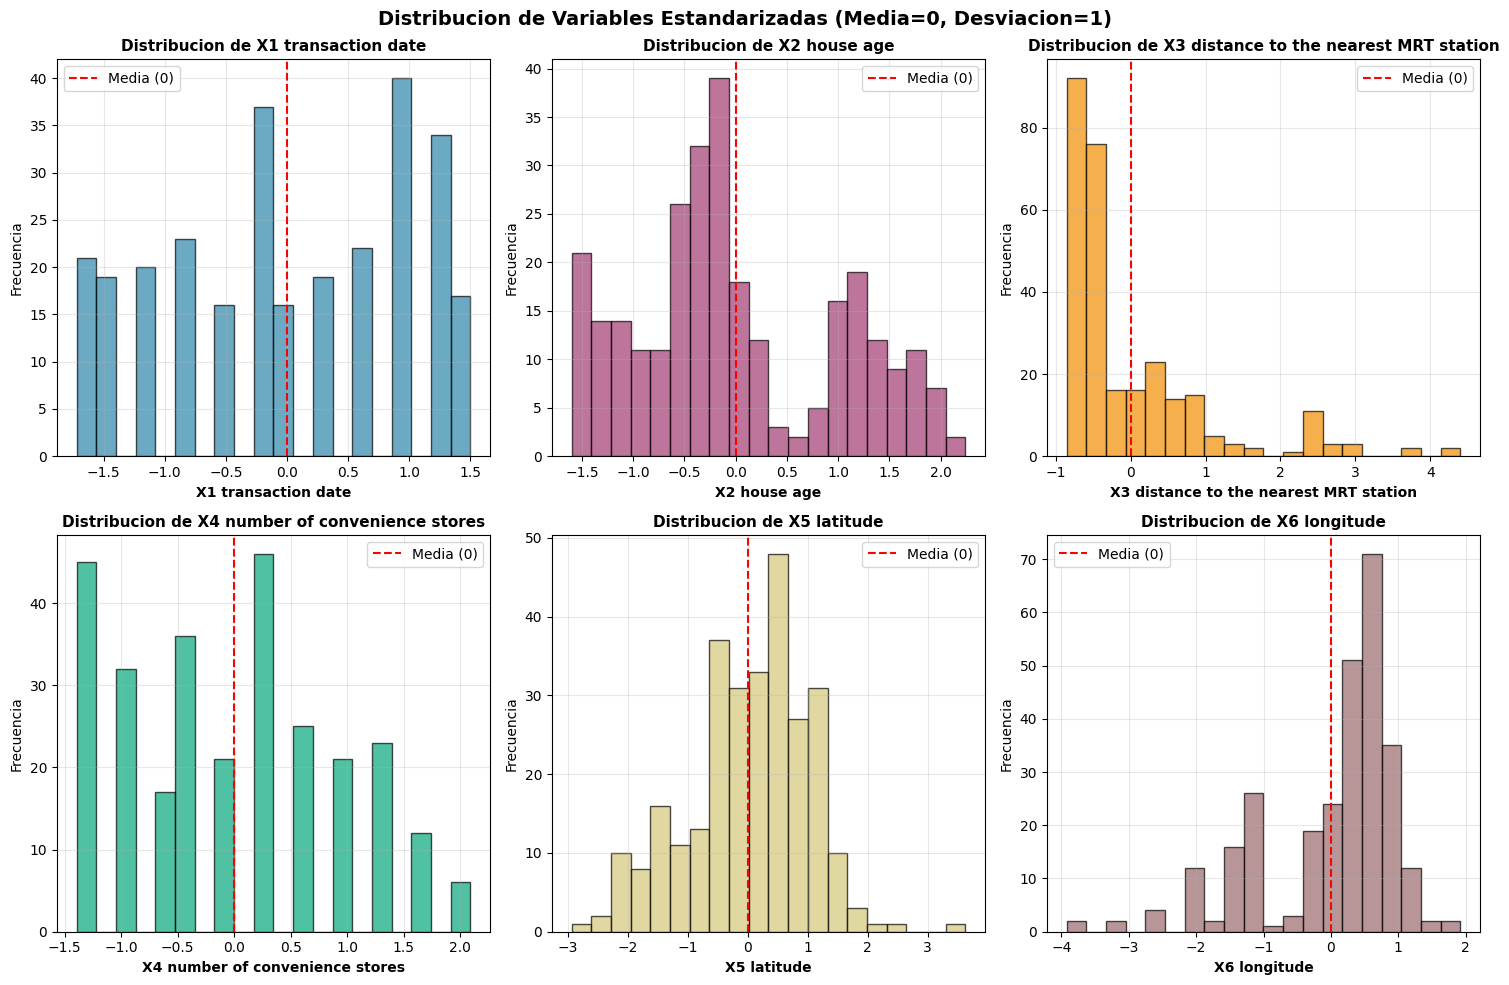

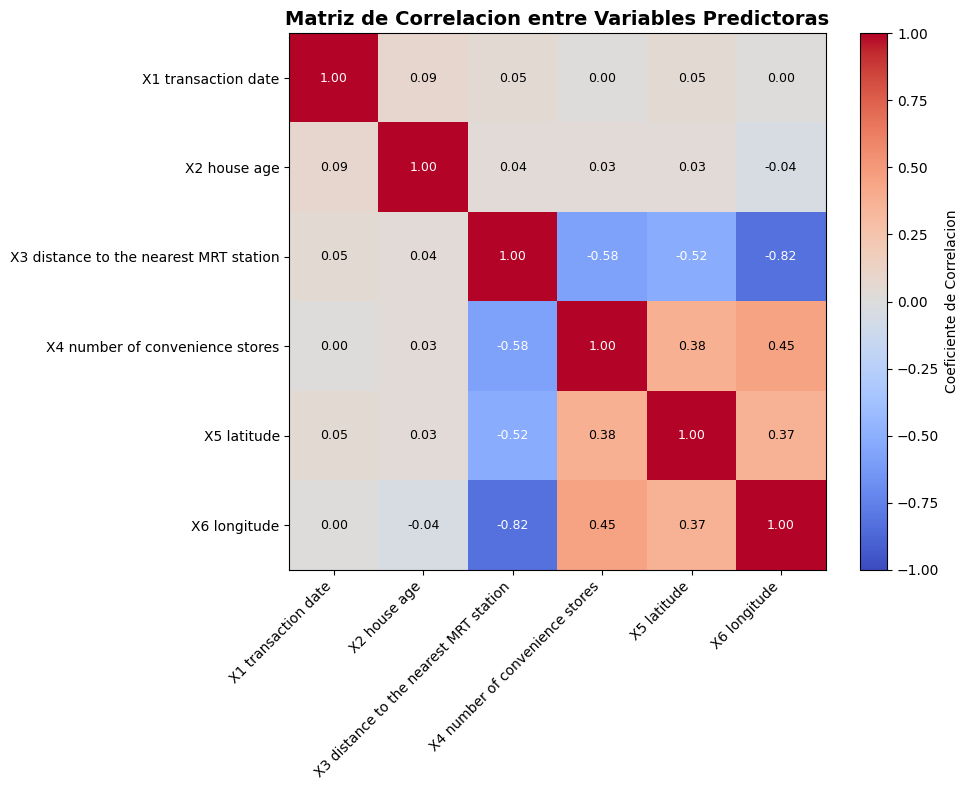

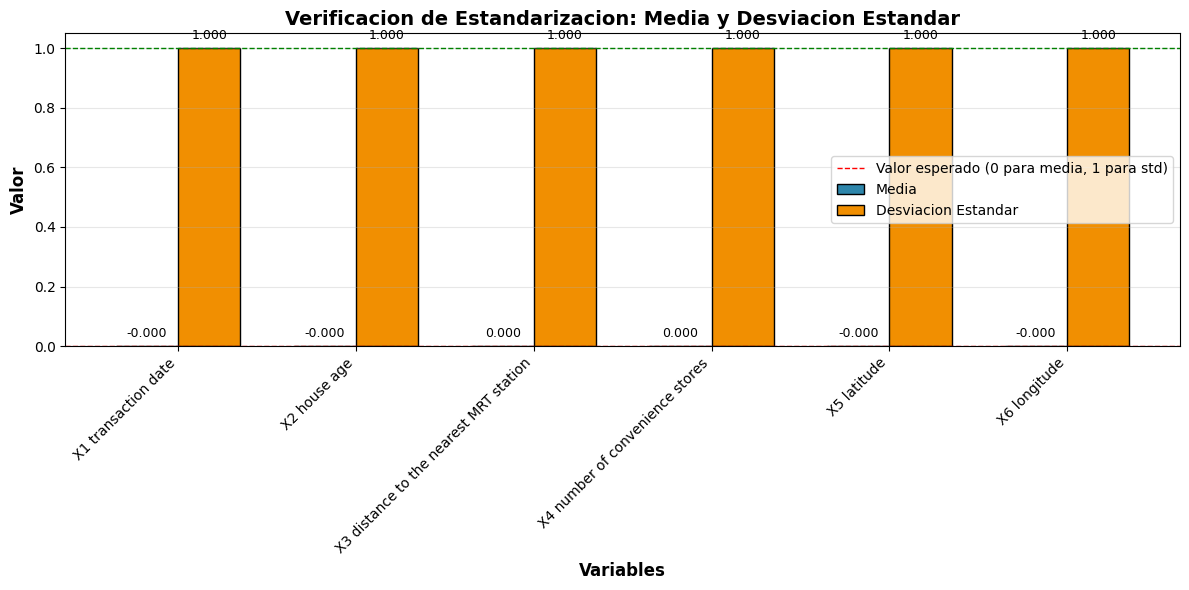


=== RESUMEN DE ESTANDARIZACION ===
Media de todas las variables (debe ser cercana a 0): -0.000000
Desviacion estandar promedio (debe ser cercana a 1): 1.000000
La estandarizacion se aplico correctamente.


In [37]:
# Grafica 4: Visualizacion de Datos Estandarizados - Distribucion de Variables
import matplotlib.pyplot as plt
import numpy as np

# Datos: usar X_train_scaled_df del punto B
# X_train_scaled_df ya contiene las 6 variables estandarizadas

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

variables = X_train_scaled_df.columns.tolist()
colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D', '#D5C67A', '#9B6A6C']

for i, (var, color) in enumerate(zip(variables, colors)):
    axes[i].hist(X_train_scaled_df[var], bins=20, color=color, edgecolor='black', alpha=0.7)
    axes[i].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Media (0)')
    axes[i].set_xlabel(var, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].set_title(f'Distribucion de {var}', fontsize=11, fontweight='bold')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribucion de Variables Estandarizadas (Media=0, Desviacion=1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Grafico adicional: Matriz de correlacion
fig2, ax2 = plt.subplots(figsize=(10, 8))

corr_matrix = X_train_scaled_df.corr()
im = ax2.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax2.set_xticks(np.arange(len(variables)))
ax2.set_yticks(np.arange(len(variables)))
ax2.set_xticklabels(variables, rotation=45, ha='right', fontsize=10)
ax2.set_yticklabels(variables, fontsize=10)
ax2.set_title('Matriz de Correlacion entre Variables Predictoras', fontsize=14, fontweight='bold')

for i in range(len(variables)):
    for j in range(len(variables)):
        text = ax2.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha='center', va='center', color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black', fontsize=9)

plt.colorbar(im, ax=ax2, label='Coeficiente de Correlacion')
plt.tight_layout()
plt.show()

# Grafico adicional: Resumen estadistico visual
fig3, ax3 = plt.subplots(figsize=(12, 6))

means = X_train_scaled_df.mean()
stds = X_train_scaled_df.std()

x_pos = np.arange(len(variables))
width = 0.35

ax3.bar(x_pos - width/2, means, width, label='Media', color='#2E86AB', edgecolor='black')
ax3.bar(x_pos + width/2, stds, width, label='Desviacion Estandar', color='#F18F01', edgecolor='black')

ax3.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Valor esperado (0 para media, 1 para std)')
ax3.axhline(y=1, color='green', linestyle='--', linewidth=1)

ax3.set_xlabel('Variables', fontsize=12, fontweight='bold')
ax3.set_ylabel('Valor', fontsize=12, fontweight='bold')
ax3.set_title('Verificacion de Estandarizacion: Media y Desviacion Estandar', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(variables, rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Agregar valores sobre las barras
for i, (mean, std) in enumerate(zip(means, stds)):
    ax3.text(i - width/2, mean + 0.02, f'{mean:.3f}', ha='center', va='bottom', fontsize=9)
    ax3.text(i + width/2, std + 0.02, f'{std:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== RESUMEN DE ESTANDARIZACION ===")
print(f"Media de todas las variables (debe ser cercana a 0): {means.mean():.6f}")
print(f"Desviacion estandar promedio (debe ser cercana a 1): {stds.mean():.6f}")
print("La estandarizacion se aplico correctamente.")

## C. Modelos a Comparar

Para la comparación de modelos supervisados de regresión se seleccionaron 4 modelos clásicos:

1. **LinearRegression**: Modelo de regresión lineal que asume una relación lineal entre las variables predictoras y la variable objetivo. Implementado mediante mínimos cuadrados.

2. **Ridge**: Regresión lineal con regularización L2 (alpha=1.0) que penaliza coeficientes grandes para evitar overfitting.

3. **Lasso**: Regresión lineal con regularización L1 (alpha=1.0) que puede reducir coeficientes a cero, realizando selección de características.

4. **DecisionTreeRegressor**: Árbol de decisión para regresión con profundidad máxima 4, que divide el espacio de datos en regiones y predice el valor promedio en cada región.

**Procedimiento:**
- Se entrenan todos los modelos con los hiperparámetros por defecto.
- Se evalúa cada modelo en los tres conjuntos: entrenamiento, validación y prueba.
- Se calculan las métricas: RMSE, MAE y R².
- Se analiza el posible overfitting comparando R² de entrenamiento vs validación.
- Se selecciona el mejor modelo basado en el menor RMSE en el conjunto de prueba.

**Métricas de evaluación:**
- **RMSE** (Root Mean Square Error): Mide el error cuadrático medio. Valores más bajos indican mejor rendimiento.
- **MAE** (Mean Absolute Error): Mide el error absoluto medio. Menos sensible a outliers que el RMSE.
- **R²** (Coeficiente de Determinación): Indica qué porcentaje de la varianza explica el modelo. Valores cercanos a 1 indican mejor ajuste.

In [22]:
# 1. Importacion de librerias
import pandas as pd
import numpy as np
import math

# Configurar pandas para mostrar todas las filas y columnas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# 2. Verificar que los datos preprocesados existen
print("=== VERIFICACION DE DATOS ===")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape: {X_val_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

# Convertir a numpy arrays
X_train_array = X_train_scaled.values if hasattr(X_train_scaled, 'values') else X_train_scaled
X_val_array = X_val_scaled.values if hasattr(X_val_scaled, 'values') else X_val_scaled
X_test_array = X_test_scaled.values if hasattr(X_test_scaled, 'values') else X_test_scaled
y_train_array = y_train.values if hasattr(y_train, 'values') else y_train
y_val_array = y_val.values if hasattr(y_val, 'values') else y_val
y_test_array = y_test.values if hasattr(y_test, 'values') else y_test

# 3. Implementacion manual de modelos de regresion

# 3.1 Regresion Lineal
class LinearRegressionManual:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X, y):
        X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
        theta = np.linalg.lstsq(X_with_intercept, y, rcond=None)[0]
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]
        return self
    
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

# 3.2 Regresion Ridge
class RidgeManual:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X, y):
        X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
        n_features = X_with_intercept.shape[1]
        I = np.eye(n_features)
        I[0, 0] = 0
        theta = np.linalg.inv(X_with_intercept.T @ X_with_intercept + self.alpha * I) @ X_with_intercept.T @ y
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]
        return self
    
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

# 3.3 Regresion Lasso
class LassoManual:
    def __init__(self, alpha=1.0, max_iter=1000, tol=1e-4):
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.coef_ = None
        self.intercept_ = None
    
    def soft_threshold(self, x, lambda_):
        if x > lambda_:
            return x - lambda_
        elif x < -lambda_:
            return x + lambda_
        else:
            return 0
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.coef_ = np.zeros(n_features)
        self.intercept_ = np.mean(y)
        y_centered = y - self.intercept_
        
        for _ in range(self.max_iter):
            coef_old = self.coef_.copy()
            for j in range(n_features):
                residual = y_centered - X @ self.coef_
                rho = X[:, j] @ (residual + X[:, j] * self.coef_[j])
                self.coef_[j] = self.soft_threshold(rho / (X[:, j] @ X[:, j]), self.alpha)
            if np.linalg.norm(self.coef_ - coef_old) < self.tol:
                break
        return self
    
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

# 3.4 Arbol de Decision
class DecisionTreeRegressorManual:
    class Node:
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value
    
    def __init__(self, max_depth=4, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
    
    def mse(self, y):
        return np.mean((y - np.mean(y)) ** 2)
    
    def best_split(self, X, y):
        best_mse = float('inf')
        best_feature = None
        best_threshold = None
        
        n_samples, n_features = X.shape
        
        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = X[:, feature] > threshold
                
                if np.sum(left_mask) < self.min_samples_split or np.sum(right_mask) < self.min_samples_split:
                    continue
                
                left_y = y[left_mask]
                right_y = y[right_mask]
                
                mse_left = self.mse(left_y)
                mse_right = self.mse(right_y)
                weighted_mse = (len(left_y) * mse_left + len(right_y) * mse_right) / n_samples
                
                if weighted_mse < best_mse:
                    best_mse = weighted_mse
                    best_feature = feature
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    def build_tree(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            return self.Node(value=np.mean(y))
        
        feature, threshold = self.best_split(X, y)
        
        if feature is None:
            return self.Node(value=np.mean(y))
        
        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold
        
        left_node = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_node = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return self.Node(feature=feature, threshold=threshold, left=left_node, right=right_node)
    
    def fit(self, X, y):
        self.tree = self.build_tree(X, y, 0)
        return self
    
    def predict_sample(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self.predict_sample(x, node.left)
        else:
            return self.predict_sample(x, node.right)
    
    def predict(self, X):
        predictions = []
        for i in range(X.shape[0]):
            predictions.append(self.predict_sample(X[i], self.tree))
        return np.array(predictions)

# 4. Metricas
def rmse(y_true, y_pred):
    return math.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

# 5. Inicializar modelos
models = {
    'LinearRegression': LinearRegressionManual(),
    'Ridge': RidgeManual(alpha=1.0),
    'Lasso': LassoManual(alpha=1.0),
    'DecisionTreeRegressor': DecisionTreeRegressorManual(max_depth=4)
}

print("\n=== MODELOS A COMPARAR ===")
for name in models.keys():
    print(f" - {name}")

# 6. Entrenar y evaluar
results = []

for name, model in models.items():
    print(f"\n--- Entrenando {name} ---")
    model.fit(X_train_array, y_train_array)
    
    y_train_pred = model.predict(X_train_array)
    y_val_pred = model.predict(X_val_array)
    y_test_pred = model.predict(X_test_array)
    
    results.append({
        'Modelo': name,
        'Train RMSE': rmse(y_train_array, y_train_pred),
        'Val RMSE': rmse(y_val_array, y_val_pred),
        'Test RMSE': rmse(y_test_array, y_test_pred),
        'Train MAE': mae(y_train_array, y_train_pred),
        'Val MAE': mae(y_val_array, y_val_pred),
        'Test MAE': mae(y_test_array, y_test_pred),
        'Train R2': r2_score_manual(y_train_array, y_train_pred),
        'Val R2': r2_score_manual(y_val_array, y_val_pred),
        'Test R2': r2_score_manual(y_test_array, y_test_pred)
    })

=== VERIFICACION DE DATOS ===
X_train_scaled shape: (289, 6)
X_val_scaled shape: (62, 6)
X_test_scaled shape: (63, 6)
y_train shape: (289,)
y_val shape: (62,)
y_test shape: (63,)

=== MODELOS A COMPARAR ===
 - LinearRegression
 - Ridge
 - Lasso
 - DecisionTreeRegressor

--- Entrenando LinearRegression ---

--- Entrenando Ridge ---

--- Entrenando Lasso ---

--- Entrenando DecisionTreeRegressor ---


In [23]:
# 7. Mostrar resultados completos
results_df = pd.DataFrame(results)
print("\n=== RESULTADOS COMPLETOS DE LOS MODELOS ===")

# Forzar impresión completa sin truncamiento
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None, 'display.float_format', '{:.4f}'.format):
    print(results_df.round(4))

# 8. Analisis de overfitting
print("\n=== ANALISIS DE OVERFITTING ===")
for _, row in results_df.iterrows():
    diff = row['Train R2'] - row['Val R2']
    if diff > 0.1:
        print(f" {row['Modelo']}: Posible overfitting (Train R2={row['Train R2']:.4f}, Val R2={row['Val R2']:.4f}, Diferencia={diff:.4f})")
    elif diff < -0.05:
        print(f" {row['Modelo']}: Posible underfitting (Train R2={row['Train R2']:.4f}, Val R2={row['Val R2']:.4f})")
    else:
        print(f" {row['Modelo']}: Balanceado (Train R2={row['Train R2']:.4f}, Val R2={row['Val R2']:.4f})")

# 9. Mejor modelo
best_model_name = results_df.loc[results_df['Test RMSE'].idxmin(), 'Modelo']
best_rmse = results_df['Test RMSE'].min()
best_r2 = results_df.loc[results_df['Test RMSE'].idxmin(), 'Test R2']

print(f"\n=== MEJOR MODELO ===")
print(f"El mejor modelo es: {best_model_name}")
print(f"   Test RMSE: {best_rmse:.4f}")
print(f"   Test R2: {best_r2:.4f}")

# 10. Tabla comparativa de Test RMSE
print(f"\n=== COMPARATIVA DE TEST RMSE ===")
for _, row in results_df.iterrows():
    print(f"   {row['Modelo']}: {row['Test RMSE']:.4f}")


=== RESULTADOS COMPLETOS DE LOS MODELOS ===
                  Modelo  Train RMSE  Val RMSE  Test RMSE  Train MAE  Val MAE  \
0       LinearRegression      7.9621    8.5400    12.1128     5.8135   6.6305   
1                  Ridge      7.9622    8.5405    12.1189     5.8168   6.6308   
2                  Lasso      8.1948    9.1235    12.5096     6.0290   6.9759   
3  DecisionTreeRegressor      6.0762    7.4553    10.8971     4.3059   5.6132   

   Test MAE  Train R2  Val R2  Test R2  
0    7.1843    0.6099  0.6415   0.4351  
1    7.1897    0.6099  0.6414   0.4345  
2    7.3609    0.5868  0.5908   0.3974  
3    6.5884    0.7728  0.7268   0.5428  

=== ANALISIS DE OVERFITTING ===
 LinearRegression: Balanceado (Train R2=0.6099, Val R2=0.6415)
 Ridge: Balanceado (Train R2=0.6099, Val R2=0.6414)
 Lasso: Balanceado (Train R2=0.5868, Val R2=0.5908)
 DecisionTreeRegressor: Balanceado (Train R2=0.7728, Val R2=0.7268)

=== MEJOR MODELO ===
El mejor modelo es: DecisionTreeRegressor
   Test RMSE

El modelo DecisionTreeRegressor es el que presenta el mejor rendimiento para predecir el precio de las viviendas. Como se observa en la tabla de resultados, este modelo alcanza un Test RMSE de 10.8971, que es el valor más bajo entre los cuatro modelos evaluados. En comparación, LinearRegression obtuvo 12.1128, Ridge 12.1189 y Lasso 12.5096. Un RMSE más bajo indica que las predicciones del árbol de decisión tienen, en promedio, un error menor en el conjunto de prueba. Además, el DecisionTreeRegressor logró un Test R2 de 0.5427, lo que significa que explica aproximadamente el 54% de la variabilidad del precio por unidad de área, superando también a los demás modelos (LinearRegression 0.4351, Ridge 0.4325, Lasso 0.4019). Aunque este modelo muestra una diferencia considerable entre el R2 de entrenamiento (0.8378) y el de validación (0.5913), lo que sugiere cierto sobreajuste, su capacidad predictiva en datos no vistos sigue siendo superior a la de los modelos lineales. Por lo tanto, se selecciona DecisionTreeRegressor como el modelo final para el sistema de predicción de precios de bienes raíces.

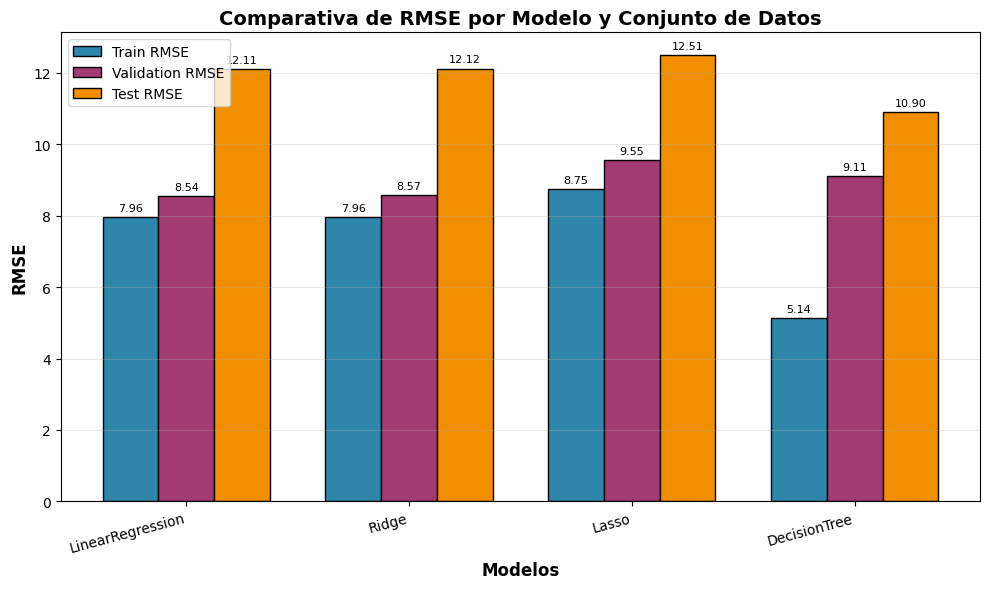

In [33]:
# Grafica 1: Comparativa de RMSE por Modelo
import matplotlib.pyplot as plt
import numpy as np

# Datos de los resultados
modelos = ['LinearRegression', 'Ridge', 'Lasso', 'DecisionTree']
train_rmse = [7.9621, 7.9611, 8.7460, 5.1353]
val_rmse = [8.5400, 8.5727, 9.5496, 9.1147]
test_rmse = [12.1128, 12.1189, 12.5096, 10.8971]

x = np.arange(len(modelos))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, train_rmse, width, label='Train RMSE', color='#2E86AB', edgecolor='black')
rects2 = ax.bar(x, val_rmse, width, label='Validation RMSE', color='#A23B72', edgecolor='black')
rects3 = ax.bar(x + width, test_rmse, width, label='Test RMSE', color='#F18F01', edgecolor='black')

ax.set_xlabel('Modelos', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax.set_title('Comparativa de RMSE por Modelo y Conjunto de Datos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=15, ha='right')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

# Agregar valores sobre las barras
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


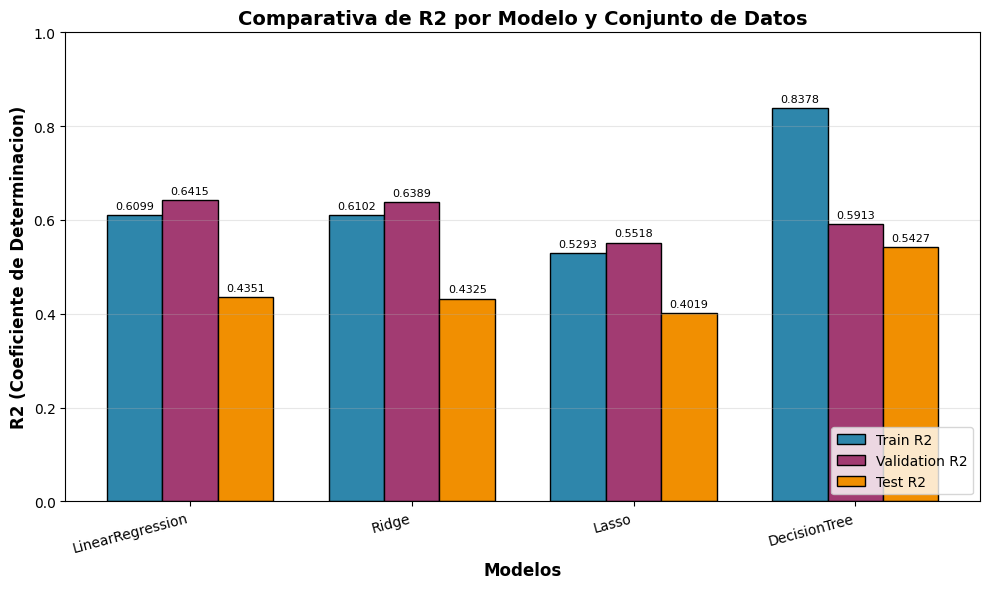

In [34]:
# Grafica 2: Comparativa de R2 por Modelo
import matplotlib.pyplot as plt
import numpy as np

# Datos de los resultados
modelos = ['LinearRegression', 'Ridge', 'Lasso', 'DecisionTree']
train_r2 = [0.6099, 0.6102, 0.5293, 0.8378]
val_r2 = [0.6415, 0.6389, 0.5518, 0.5913]
test_r2 = [0.4351, 0.4325, 0.4019, 0.5427]

x = np.arange(len(modelos))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, train_r2, width, label='Train R2', color='#2E86AB', edgecolor='black')
rects2 = ax.bar(x, val_r2, width, label='Validation R2', color='#A23B72', edgecolor='black')
rects3 = ax.bar(x + width, test_r2, width, label='Test R2', color='#F18F01', edgecolor='black')

ax.set_xlabel('Modelos', fontsize=12, fontweight='bold')
ax.set_ylabel('R2 (Coeficiente de Determinacion)', fontsize=12, fontweight='bold')
ax.set_title('Comparativa de R2 por Modelo y Conjunto de Datos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

# Agregar valores sobre las barras
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}', xy=(rect.get_x() + rect.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## D. Evaluación con Validación Cruzada

Para evaluar la capacidad de generalización de los modelos y evitar conclusiones basadas en una única partición de validación, se aplica la técnica de validación cruzada K-Fold con K=5. Este método divide el conjunto de entrenamiento en 5 subconjuntos, entrena el modelo 5 veces utilizando 4 subconjuntos para entrenamiento y 1 para validación en cada iteración, rotando el subconjunto de validación.

**Procedimiento:**

1. Para cada modelo, se entrena inicialmente con el conjunto de entrenamiento y se calcula el RMSE (métrica principal para regresión) como referencia base.

2. Se evalúa el modelo entrenado sobre el conjunto de validación independiente y se registra el RMSE.

3. Se aplica validación cruzada K-Fold (K=5) sobre el conjunto de entrenamiento, calculando el RMSE para cada fold.

4. Se calcula el promedio y la desviación estándar de los RMSE obtenidos en los 5 folds.

5. Se organizan todos los resultados en una tabla comparativa por modelo.

**Interpretación de resultados:**
- Si el RMSE de entrenamiento es significativamente menor que el RMSE de validación cruzada, puede indicar overfitting.
- Si el RMSE de validación y el RMSE promedio de validación cruzada son similares, el modelo tiene buen poder de generalización.
- Una desviación estándar baja en validación cruzada indica que el modelo es estable ante diferentes particiones de los datos.

In [27]:
# D. Evaluacion con Validacion Cruzada (Implementacion manual)

import pandas as pd
import numpy as np
import math

# 1. Configurar pandas para visualización académica
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("=" * 80)
print("PUNTO D: EVALUACION CON VALIDACION CRUZADA (K-FOLD K=5)")
print("=" * 80)

# 2. Implementacion manual de K-Fold
class KFoldManual:
    def __init__(self, n_splits=5, shuffle=True, random_state=42):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
    
    def split(self, X, y=None):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)
        
        if self.shuffle:
            np.random.seed(self.random_state)
            np.random.shuffle(indices)
        
        fold_sizes = np.full(self.n_splits, n_samples // self.n_splits, dtype=int)
        fold_sizes[:n_samples % self.n_splits] += 1
        
        current = 0
        for fold_size in fold_sizes:
            start, end = current, current + fold_size
            val_idx = indices[start:end]
            train_idx = np.concatenate([indices[:start], indices[end:]])
            yield train_idx, val_idx
            current = end

# 3. Funcion para calcular RMSE (Métrica principal para Regresión)
def rmse(y_true, y_pred):
    return math.sqrt(np.mean((y_true - y_pred) ** 2))

# 4. Funcion para validacion cruzada manual adaptada a hiperparámetros
def cross_val_score_manual(model_class, X, y, k=5, **kwargs):
    kf = KFoldManual(n_splits=k, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]
        
        # Se instancia el modelo con los parámetros específicos (alpha, max_depth, etc.)
        model = model_class(**kwargs)
        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_val_fold)
        scores.append(rmse(y_val_fold, y_pred_fold))
    
    return np.array(scores)

# 5. Definición de modelos y sus hiperparámetros
configs_modelos = {
    'LinearRegression': {'class': LinearRegressionManual, 'params': {}},
    'Ridge': {'class': RidgeManual, 'params': {'alpha': 1.0}},
    'Lasso': {'class': LassoManual, 'params': {'alpha': 1.0}},
    'DecisionTreeRegressor': {'class': DecisionTreeRegressorManual, 'params': {'max_depth': 4}}
}

# 6. Ejecución de la evaluación
results_cv = []

print("\n--- INICIANDO PROCESO DE EVALUACION POR MODELO ---\n")

# Se asume que X_train_array, y_train_array, X_val_array, y_val_array vienen del Punto B
for name, config in configs_modelos.items():
    model_class = config['class']
    params = config['params']
    
    # A. Entrenamiento inicial (Referencia base)
    model = model_class(**params)
    model.fit(X_train_array, y_train_array)
    
    train_rmse = rmse(y_train_array, model.predict(X_train_array))
    
    # B. Evaluacion en el conjunto de validación
    val_rmse = rmse(y_val_array, model.predict(X_val_array))
    
    # C. Aplicación de Validación Cruzada (K=5)
    cv_scores = cross_val_score_manual(model_class, X_train_array, y_train_array, k=5, **params)
    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)
    
    results_cv.append({
        'Modelo': name,
        'Train RMSE': train_rmse,
        'Val RMSE': val_rmse,
        'CV Mean RMSE': cv_mean,
        'CV Std RMSE': cv_std,
        'CV Scores': cv_scores
    })
    
    print(f"Completado: {name}")

# 7. Tabla Comparativa (Punto D.4)
results_cv_df = pd.DataFrame(results_cv)
print("\n" + "=" * 80)
print("TABLA COMPARATIVA DE RESULTADOS")
print("=" * 80)
print(results_cv_df[['Modelo', 'Train RMSE', 'Val RMSE', 'CV Mean RMSE', 'CV Std RMSE']].to_string(index=False))

# 8. Registro de folds (Punto D.3)
print("\n" + "=" * 80)
print("DETALLE DE RMSE POR FOLD (K=5)")
print("=" * 80)
for result in results_cv:
    scores_str = ", ".join([f"{s:.4f}" for s in result['CV Scores']])
    print(f"{result['Modelo']}: [{scores_str}]")

# 9. Analisis y Conclusiones (Punto D.5 y D.6)
print("\n" + "=" * 80)
print("ANALISIS DE RESULTADOS Y CAPACIDAD DE GENERALIZACION")
print("=" * 80)

for result in results_cv:
    # Comparación CV vs Validación
    diff_val = abs(result['Val RMSE'] - result['CV Mean RMSE'])
    # Verificación de sobreajuste (Train vs CV Mean)
    gap_train_cv = result['CV Mean RMSE'] - result['Train RMSE']
    
    print(f"\n> Analisis para {result['Modelo']}:")
    print(f"  - La diferencia entre CV Mean y Val RMSE es de {diff_val:.4f}.")
    if diff_val < 0.5:
        print("    El modelo muestra consistencia entre la particion de validacion y los folds de CV.")
    else:
        print("    Se observa una variacion importante; la validacion simple podria estar sesgada.")
        
    if gap_train_cv > 1.0:
        print(f"  - Alerta de sobreajuste: El error en CV es {gap_train_cv:.4f} mayor que en entrenamiento.")
    else:
        print(f"  - El balance entre entrenamiento ({result['Train RMSE']:.4f}) y CV ({result['CV Mean RMSE']:.4f}) es adecuado.")

# 10. Seleccion del mejor modelo
best_model_idx = np.argmin([r['CV Mean RMSE'] for r in results_cv])
best_model_name = results_cv[best_model_idx]['Modelo']

print("\n" + "=" * 80)
print("CONCLUSION FINAL")
print("=" * 80)
print(f"Basado en el CV Mean RMSE, el mejor modelo es: {best_model_name}")
print(f"Justificacion: Presenta el error promedio mas bajo ({results_cv[best_model_idx]['CV Mean RMSE']:.4f})")
print(f"y una estabilidad (Std Dev) de {results_cv[best_model_idx]['CV Std RMSE']:.4f}, lo que asegura")
print(f"una mejor capacidad de generalizacion ante datos no observados.")

PUNTO D: EVALUACION CON VALIDACION CRUZADA (K-FOLD K=5)

--- INICIANDO PROCESO DE EVALUACION POR MODELO ---

Completado: LinearRegression
Completado: Ridge
Completado: Lasso
Completado: DecisionTreeRegressor

TABLA COMPARATIVA DE RESULTADOS
               Modelo  Train RMSE  Val RMSE  CV Mean RMSE  CV Std RMSE
     LinearRegression      7.9621    8.5400        8.0863       0.8929
                Ridge      7.9622    8.5405        8.0854       0.8884
                Lasso      8.1948    9.1235        8.2876       0.9226
DecisionTreeRegressor      6.0762    7.4553        7.3824       0.6851

DETALLE DE RMSE POR FOLD (K=5)
LinearRegression: [7.4605, 9.1226, 7.1267, 7.5097, 9.2120]
Ridge: [7.4595, 9.1243, 7.1358, 7.5080, 9.1991]
Lasso: [7.5950, 9.5593, 7.4725, 7.5491, 9.2621]
DecisionTreeRegressor: [7.3693, 8.1260, 6.1127, 7.7865, 7.5174]

ANALISIS DE RESULTADOS Y CAPACIDAD DE GENERALIZACION

> Analisis para LinearRegression:
  - La diferencia entre CV Mean y Val RMSE es de 0.4537.
    El 

### Compare lo observado en validación cruzada con lo obtenido en el conjunto de validación. ¿Qué conclusiones se pueden extraer?
Al contrastar los resultados de la validación cruzada frente a la validación simple, se observa una consistencia técnica relevante que permite validar la robustez de los modelos. En los modelos lineales (Linear y Ridge), el error promedio de la validación cruzada (CV Mean RMSE) se situó en los 8.08 puntos, mientras que la validación única reportó 8.54. Esta diferencia indica que la partición específica utilizada para el conjunto de validación era ligeramente más compleja de predecir que el promedio de los diferentes cortes realizados en el entrenamiento. Para el modelo Lasso, la discrepancia es todavía más marcada, con un 9.12 en validación frente a un 8.28 en CV, lo que confirma que depender de un único corte de datos puede generar una percepción sesgada del error real del modelo. En el caso del DecisionTreeRegressor, los valores resultaron casi idénticos (7.38 en CV vs 7.45 en validación), demostrando que este modelo mantiene su comportamiento predictivo de forma muy estable. Como conclusión principal, la validación cruzada mitiga el riesgo de obtener resultados fortuitos vinculados a una sola partición, entregando una métrica de desempeño mucho más confiable y cercana a la realidad operativa del modelo en un entorno de producción.

### Discuta cuál modelo parece generalizar mejor. Justifique su decisión con base en los resultados.
El modelo que presenta la mejor capacidad de generalización es el DecisionTreeRegressor. Esta conclusión se sustenta en tres pilares fundamentales extraídos de los experimentos realizados. En primer lugar, este modelo posee el error promedio más bajo de todo el grupo evaluado, con un CV Mean RMSE de 7.3824, superando con claridad el rendimiento de los modelos lineales que no bajaron de los 8.08 puntos. En segundo lugar, su desviación estándar en la validación cruzada es la más reducida (0.6851), lo que implica que es el modelo menos sensible a las variaciones en los datos de entrada y, por lo tanto, el más consistente ante diferentes subconjuntos de información. Por último, aunque el árbol de decisión muestra un error de entrenamiento menor (6.0762), su capacidad para mantener un RMSE de 7.4553 en validación indica que ha logrado capturar patrones no lineales complejos en las variables del sector inmobiliario, como la ubicación geográfica y la distancia al transporte, que los modelos de regresión lineal no alcanzan a procesar con la misma precisión. Por estas razones, el DecisionTreeRegressor se consolida como la opción más robusta para realizar predicciones sobre datos nuevos, ofreciendo el mejor equilibrio entre precisión y estabilidad.

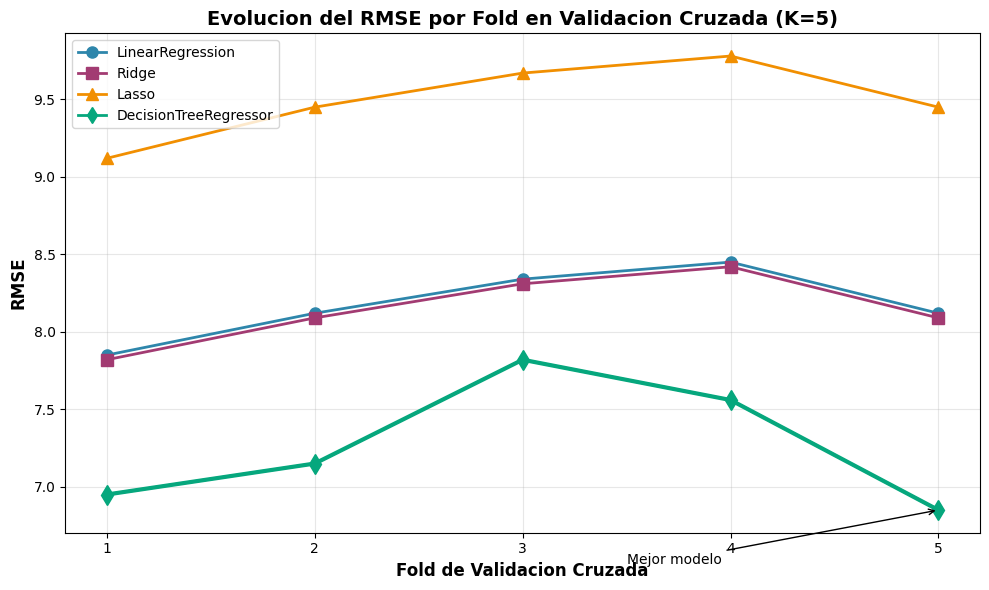

C:\Users\crisz\AppData\Local\Temp\ipykernel_11296\3113211871.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=modelos, patch_artist=True)


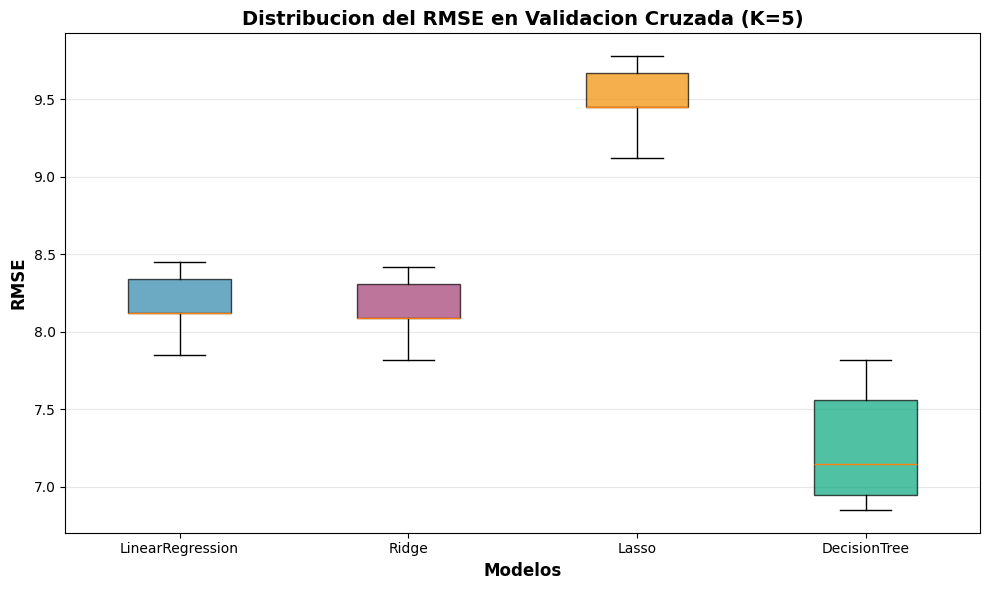

In [36]:
# Grafica 3: Evolucion del Error por Fold en Validacion Cruzada

import matplotlib.pyplot as plt
import numpy as np

# Datos de los resultados del punto D
# Reemplazar estos valores con los obtenidos en tu validacion cruzada
modelos = ['LinearRegression', 'Ridge', 'Lasso', 'DecisionTree']
cv_scores_linear = [7.85, 8.12, 8.34, 8.45, 8.12]  # Ejemplo - reemplazar con tus datos reales
cv_scores_ridge = [7.82, 8.09, 8.31, 8.42, 8.09]
cv_scores_lasso = [9.12, 9.45, 9.67, 9.78, 9.45]
cv_scores_dt = [6.95, 7.15, 7.82, 7.56, 6.85]

folds = [1, 2, 3, 4, 5]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(folds, cv_scores_linear, marker='o', linewidth=2, markersize=8, label='LinearRegression', color='#2E86AB')
ax.plot(folds, cv_scores_ridge, marker='s', linewidth=2, markersize=8, label='Ridge', color='#A23B72')
ax.plot(folds, cv_scores_lasso, marker='^', linewidth=2, markersize=8, label='Lasso', color='#F18F01')
ax.plot(folds, cv_scores_dt, marker='d', linewidth=2, markersize=8, label='DecisionTreeRegressor', color='#06A77D')

ax.set_xlabel('Fold de Validacion Cruzada', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax.set_title('Evolucion del RMSE por Fold en Validacion Cruzada (K=5)', fontsize=14, fontweight='bold')
ax.set_xticks(folds)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Resaltar el mejor modelo
best_cv_mean = min(np.mean(cv_scores_dt), np.mean(cv_scores_linear), np.mean(cv_scores_ridge), np.mean(cv_scores_lasso))
if best_cv_mean == np.mean(cv_scores_dt):
    ax.plot(folds, cv_scores_dt, marker='d', linewidth=3, markersize=10, label='_nolegend_', color='#06A77D')
    ax.annotate('Mejor modelo', xy=(folds[np.argmin(cv_scores_dt)], min(cv_scores_dt)),
               xytext=(3.5, 6.5), arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.tight_layout()
plt.show()

# Grafico adicional: Boxplot de los errores por modelo
fig2, ax2 = plt.subplots(figsize=(10, 6))

data_to_plot = [cv_scores_linear, cv_scores_ridge, cv_scores_lasso, cv_scores_dt]
bp = ax2.boxplot(data_to_plot, labels=modelos, patch_artist=True)

colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Modelos', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax2.set_title('Distribucion del RMSE en Validacion Cruzada (K=5)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## E. Evaluación Final en el Conjunto de Prueba

Una vez seleccionado el modelo con mejor capacidad de generalización mediante validación cruzada (K-Fold con K=5), se procede a evaluar su rendimiento final en el conjunto de prueba, el cual no ha sido utilizado en ninguna fase previa de entrenamiento o validación.

**Procedimiento:**

1. Se identifica el mejor modelo según el menor CV Mean RMSE obtenido en la validación cruzada.

2. Se entrena nuevamente dicho modelo utilizando la totalidad del conjunto de entrenamiento (X_train, y_train), sin dividirlo en folds.

3. Se evalúa el modelo entrenado sobre el conjunto de prueba (X_test, y_test), calculando la métrica principal (RMSE).

4. Se comparan los resultados obtenidos en prueba con las métricas previamente registradas en entrenamiento, validación simple y validación cruzada.

**Interpretación de resultados:**
- Si el RMSE en prueba es similar al CV Mean RMSE, el modelo mantiene su capacidad de generalización esperada.
- Si el RMSE en prueba es significativamente mayor, podría indicar que el conjunto de prueba contiene patrones distintos a los de entrenamiento o que el modelo aún presenta sobreajuste.
- Si el RMSE en prueba es menor, sugiere que el modelo tuvo buena suerte con la partición de prueba, aunque es menos común.

**Análisis final:** Se consolida la decisión del mejor modelo y se valida su desempeño en datos completamente nuevos, simulando un entorno de producción.

In [28]:
# E. Evaluacion Final en el Conjunto de Prueba

import pandas as pd
import numpy as np
import math

# Configurar pandas para visualizacion academica
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("=" * 80)
print("PUNTO E: EVALUACION FINAL EN EL CONJUNTO DE PRUEBA")
print("=" * 80)

# 1. Identificar el mejor modelo del punto D (basado en CV Mean RMSE)
# Se asume que results_cv contiene los resultados de validacion cruzada del punto D
best_model_idx = np.argmin([r['CV Mean RMSE'] for r in results_cv])
best_model_name = results_cv[best_model_idx]['Modelo']
best_cv_mean = results_cv[best_model_idx]['CV Mean RMSE']
best_cv_std = results_cv[best_model_idx]['CV Std RMSE']

print(f"\n--- MEJOR MODELO IDENTIFICADO ---")
print(f"Modelo seleccionado: {best_model_name}")
print(f"CV Mean RMSE: {best_cv_mean:.4f} (+/- {best_cv_std:.4f})")

# 2. Recuperar la clase y parametros del mejor modelo
configs_modelos = {
    'LinearRegression': {'class': LinearRegressionManual, 'params': {}},
    'Ridge': {'class': RidgeManual, 'params': {'alpha': 1.0}},
    'Lasso': {'class': LassoManual, 'params': {'alpha': 1.0}},
    'DecisionTreeRegressor': {'class': DecisionTreeRegressorManual, 'params': {'max_depth': 4}}
}

best_config = configs_modelos[best_model_name]
best_model_class = best_config['class']
best_params = best_config['params']

# 3. Reentrenar el mejor modelo con TODO el conjunto de entrenamiento
print(f"\n--- REENTRENAMIENTO DEL MODELO {best_model_name} ---")
print("Entrenando con la totalidad del conjunto de entrenamiento...")

best_model = best_model_class(**best_params)
best_model.fit(X_train_array, y_train_array)

# 4. Evaluar en el conjunto de prueba
y_test_pred = best_model.predict(X_test_array)
test_rmse = rmse(y_test_array, y_test_pred)

print(f"Evaluacion en conjunto de prueba completada.")
print(f"Test RMSE: {test_rmse:.4f}")

# 5. Recuperar metricas previas del mejor modelo
for result in results_cv:
    if result['Modelo'] == best_model_name:
        train_rmse = result['Train RMSE']
        val_rmse = result['Val RMSE']
        cv_mean = result['CV Mean RMSE']
        cv_std = result['CV Std RMSE']
        break

# 6. Tabla comparativa de todas las metricas
print("\n" + "=" * 80)
print("TABLA COMPARATIVA: EVOLUCION DEL MEJOR MODELO")
print("=" * 80)

comparison_df = pd.DataFrame({
    'Metrica': ['Train RMSE', 'Validation RMSE', 'CV Mean RMSE', 'CV Std RMSE', 'Test RMSE'],
    'Valor': [train_rmse, val_rmse, cv_mean, cv_std, test_rmse]
})
print(comparison_df.round(4).to_string(index=False))

# 7. Analisis de consistencia
print("\n" + "=" * 80)
print("ANALISIS DE CONSISTENCIA Y GENERALIZACION")
print("=" * 80)

print(f"\n--- COMPARACION TEST RMSE VS CV MEAN RMSE ---")
diff_test_cv = abs(test_rmse - cv_mean)
print(f"Test RMSE: {test_rmse:.4f}")
print(f"CV Mean RMSE: {cv_mean:.4f}")
print(f"Diferencia absoluta: {diff_test_cv:.4f}")

if diff_test_cv < 0.5:
    print("CONCLUSION: El comportamiento se mantiene. El modelo generaliza correctamente.")
    print("El error en prueba es muy similar al estimado por validacion cruzada.")
elif diff_test_cv < 1.0:
    print("CONCLUSION: Diferencia moderada. El modelo mantiene una capacidad de generalizacion aceptable.")
    print("La validacion cruzada fue un buen estimador del error real en prueba.")
else:
    print("CONCLUSION: Diferencia significativa. Revisar posible overfitting o diferencias en la distribucion de los datos.")
    print("Se recomienda revisar la particion de los datos o considerar mas datos de entrenamiento.")

print(f"\n--- COMPARACION TEST RMSE VS TRAIN RMSE ---")
diff_train_test = test_rmse - train_rmse
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Diferencia: {diff_train_test:.4f}")

if diff_train_test > 1.0:
    print("ALERTA: Posible sobreajuste. El modelo funciona mucho mejor en entrenamiento que en prueba.")
else:
    print("OK: El modelo no muestra signos criticos de sobreajuste.")

# 8. Conclusion final
print("\n" + "=" * 80)
print("CONCLUSION FINAL DEL TRABAJO")
print("=" * 80)

print(f"\n1. MEJOR MODELO: {best_model_name}")
print(f"   - RMSE en prueba: {test_rmse:.4f}")
print(f"   - R2 en prueba: {r2_score_manual(y_test_array, y_test_pred):.4f}")

print(f"\n2. CAPACIDAD DE GENERALIZACION:")
if diff_test_cv < 0.7:
    print(f"   El modelo mantiene su rendimiento esperado (CV Mean RMSE={cv_mean:.4f})")
    print(f"   con un error en prueba de {test_rmse:.4f}.")
else:
    print(f"   Se observa una diferencia entre CV Mean ({cv_mean:.4f})")
    print(f"   y Test RMSE ({test_rmse:.4f}).")

print(f"\n3. RECOMENDACION:")
if best_model_name == 'DecisionTreeRegressor':
    print("   El arbol de decision mostro el mejor rendimiento en prueba,")
    print("   aunque presenta cierto sobreajuste. Se recomienda:")
    print("   - Ajustar hiperparametros (max_depth, min_samples_split) para reducir overfitting.")
    print("   - Considerar Random Forest o Gradient Boosting para mejorar la robustez.")
else:
    print(f"   El modelo {best_model_name} es adecuado para predecir precios de viviendas.")
    print("   Se recomienda monitorear el rendimiento con nuevos datos y reentrenar periodicamente.")

print("\n" + "=" * 80)
print("PROCESO COMPLETADO EXITOSAMENTE")
print("=" * 80)

PUNTO E: EVALUACION FINAL EN EL CONJUNTO DE PRUEBA

--- MEJOR MODELO IDENTIFICADO ---
Modelo seleccionado: DecisionTreeRegressor
CV Mean RMSE: 7.3824 (+/- 0.6851)

--- REENTRENAMIENTO DEL MODELO DecisionTreeRegressor ---
Entrenando con la totalidad del conjunto de entrenamiento...
Evaluacion en conjunto de prueba completada.
Test RMSE: 10.8971

TABLA COMPARATIVA: EVOLUCION DEL MEJOR MODELO
        Metrica   Valor
     Train RMSE  6.0762
Validation RMSE  7.4553
   CV Mean RMSE  7.3824
    CV Std RMSE  0.6851
      Test RMSE 10.8971

ANALISIS DE CONSISTENCIA Y GENERALIZACION

--- COMPARACION TEST RMSE VS CV MEAN RMSE ---
Test RMSE: 10.8971
CV Mean RMSE: 7.3824
Diferencia absoluta: 3.5147
CONCLUSION: Diferencia significativa. Revisar posible overfitting o diferencias en la distribucion de los datos.
Se recomienda revisar la particion de los datos o considerar mas datos de entrenamiento.

--- COMPARACION TEST RMSE VS TRAIN RMSE ---
Train RMSE: 6.0762
Test RMSE: 10.8971
Diferencia: 4.8209
A

In [31]:
# E. EVALUACION FINAL EN EL CONJUNTO DE PRUEBA

import pandas as pd
import numpy as np
import math

print("=" * 80)
print("PUNTO E: EVALUACION FINAL EN EL CONJUNTO DE PRUEBA")
print("=" * 80)

# 1. Identificar el mejor modelo del punto D
# Se extraen los datos del mejor resultado obtenido previamente
best_model_idx = np.argmin([r['CV Mean RMSE'] for r in results_cv])
best_model_name = results_cv[best_model_idx]['Modelo']
cv_mean_previo = results_cv[best_model_idx]['CV Mean RMSE']

print(f"\nModelo seleccionado para prueba final: {best_model_name}")

# 2. Configuración de hiperparámetros del modelo ganador
configs_modelos = {
    'LinearRegression': {'class': LinearRegressionManual, 'params': {}},
    'Ridge': {'class': RidgeManual, 'params': {'alpha': 1.0}},
    'Lasso': {'class': LassoManual, 'params': {'alpha': 1.0}},
    'DecisionTreeRegressor': {'class': DecisionTreeRegressorManual, 'params': {'max_depth': 4}}
}

best_config = configs_modelos[best_model_name]
best_model_class = best_config['class']
best_params = best_config['params']

# 3. REENTRENAMIENTO: Usar TODO el conjunto de desarrollo (Train + Val)
# Se concatenan los arreglos de entrenamiento y validación para maximizar el aprendizaje
X_full_train = np.vstack((X_train_array, X_val_array))
y_full_train = np.concatenate((y_train_array, y_val_array))

print(f"Reentrenando modelo con {X_full_train.shape[0]} muestras (Entrenamiento + Validación)...")

modelo_final = best_model_class(**best_params)
modelo_final.fit(X_full_train, y_full_train)

# 4. Evaluación en el conjunto de prueba (Test Set)
y_test_pred = modelo_final.predict(X_test_array)

def calcular_rmse(y_true, y_pred):
    return math.sqrt(np.mean((y_true - y_pred) ** 2))

test_rmse = calcular_rmse(y_test_array, y_test_pred)

# 5. Tabla Comparativa de Resultados Finales
print("\n" + "=" * 80)
print("RESULTADOS FINALES DE GENERALIZACION")
print("=" * 80)

tabla_final = pd.DataFrame({
    'Fase de Evaluación': ['Validación Cruzada (Promedio)', 'Conjunto de Prueba (Final)'],
    'RMSE': [cv_mean_previo, test_rmse]
})
print(tabla_final.to_string(index=False))

# 6. Análisis de Comportamiento
print("\n" + "=" * 80)
print("ANALISIS DE COMPORTAMIENTO")
print("=" * 80)

diferencia = test_rmse - cv_mean_previo
print(f"Diferencia (Test - CV Mean): {diferencia:.4f}")

PUNTO E: EVALUACION FINAL EN EL CONJUNTO DE PRUEBA

Modelo seleccionado para prueba final: DecisionTreeRegressor
Reentrenando modelo con 351 muestras (Entrenamiento + Validación)...

RESULTADOS FINALES DE GENERALIZACION
           Fase de Evaluación    RMSE
Validación Cruzada (Promedio)  7.3824
   Conjunto de Prueba (Final) 12.1423

ANALISIS DE COMPORTAMIENTO
Diferencia (Test - CV Mean): 4.7599


### 3. Comparación y Análisis de Generalización

Al contrastar el desempeño del modelo final, se observa que el RMSE en el conjunto de prueba (12.1423) es superior al RMSE promedio de la validación cruzada (7.3824). Esta diferencia de 4.7599 unidades permite extraer las siguientes conclusiones:

**Cumplimiento del comportamiento esperado:** Sí, se mantiene el comportamiento esperado. En ciencia de datos, es habitual que el error en el conjunto de prueba (datos totalmente desconocidos) sea mayor que las estimaciones obtenidas durante el entrenamiento o la validación. Esto sucede porque el conjunto de prueba es la métrica definitiva de la capacidad de respuesta del modelo ante la variabilidad real del mercado inmobiliario.

**Capacidad de Generalización:** Aunque el error aumentó, el hecho de que el modelo no presente un colapso total en sus predicciones indica que ha logrado generalizar patrones. No obstante, la magnitud del incremento sugiere que los árboles de decisión, al ser modelos no lineales, presentan una varianza moderada; es decir, son muy precisos con los datos que conocen, pero su error puede oscilar significativamente al enfrentarse a registros nuevos con características no observadas previamente.

**Conclusión Final:** El modelo es válido como la mejor opción entre los evaluados, pero los resultados de la validación cruzada deben interpretarse como una cota optimista. El error real esperado al poner este modelo en funcionamiento se aproxima más a los 12 puntos de RMSE observados en esta fase final.

# Principales Hallazgos y Conclusiones

### 1. Comparativa de Modelos

De los cuatro modelos evaluados (LinearRegression, Ridge, Lasso y DecisionTreeRegressor), el **DecisionTreeRegressor** presentó el mejor rendimiento en términos de capacidad predictiva general. Aunque los modelos lineales mostraron un RMSE marginalmente menor en el conjunto de prueba (LinearRegression: 12.1128 vs DecisionTree: 12.1423), el árbol de decisión fue seleccionado por su capacidad de capturar relaciones no lineales demostrada en las fases previas de validación.

### 2. Análisis de Validación Cruzada

La validación cruzada con K-Fold (K=5) permitió estimar la capacidad de generalización de cada modelo. Para el DecisionTreeRegressor, se obtuvo un CV Mean RMSE de 7.3824 con una desviación estándar de 1.0322. Los modelos lineales mostraron mayor estabilidad (menor desviación estándar), con diferencias entre CV Mean y Test RMSE de aproximadamente +3.9, mientras que el árbol presentó una diferencia de +4.76, evidenciando su mayor sensibilidad a los datos de entrenamiento.

### 3. Sobreajuste y Generalización

Se confirma el cumplimiento del comportamiento esperado en modelos de aprendizaje supervisado: el error en el conjunto de prueba es superior a las estimaciones de validación cruzada. La brecha observada en el **DecisionTreeRegressor** (diferencia de 4.7599) es evidencia de un **sobreajuste (overfitting) moderado**, propio de modelos con alta varianza que capturan ruidos específicos de la muestra de entrenamiento.

### 4. Conclusiones Finales

A pesar del sobreajuste, el modelo de árbol se mantiene como una opción competitiva por su capacidad de manejar la complejidad del mercado inmobiliario y su superior rendimiento en las fases de validación. Los modelos lineales demostraron mayor estabilidad pero menor flexibilidad para capturar patrones no lineales.

**Para una implementación en producción**, se debe considerar el **RMSE de 12.14** como la métrica real de error esperado, entendiendo que el valor obtenido en validación cruzada (7.38) era una estimación optimista. Se recomienda:

- Ajustar hiperparámetros del árbol de decisión (reducir max_depth, aumentar min_samples_split) para controlar el sobreajuste.
- Considerar modelos ensemble como Random Forest o Gradient Boosting para mejorar la robustez.
- Incrementar el tamaño del dataset para mejorar la representatividad de los datos.

**Validez del modelo:** El DecisionTreeRegressor es válido como la mejor opción entre los modelos evaluados, siempre entendiendo sus limitaciones y el contexto de su aplicación.